# 10 - Price Timing Predictor

Predict whether a product's price is likely to drop in the near future, and recommend optimal purchase timing to users. Using the product_price_history dataset.

## 1. Data Loading

The product_price_history dataset contains one row per (product_id, date) pair and covers October–November 2019.

In [24]:
%pip install fastparquet

  Using cached fastparquet-2026.3.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (4.8 kB)
Using cached fastparquet-2026.3.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.8 MB)
Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np 
import pandas as pd
import fastparquet
 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
    average_precision_score, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
df = pd.read_parquet('/kaggle/input/datasets/kylenaluan/product-price-history')

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique products: {df['product_id'].nunique()}")
df.head()

Shape: (4998112, 7)
Date range: 2019-10-01 00:00:00+00:00 to 2019-11-30 00:00:00+00:00
Unique products: 206876


,product_id,date,median_price,price_30d_avg,price_30d_min,price_30d_max,price_30d_pct
0,1000365,2019-11-05 00:00:00+00:00,1029.089966,1029.089966,1029.089966,1029.089966,0.5
1,1000978,2019-10-21 00:00:00+00:00,333.489990,333.489990,333.489990,333.489990,0.5
2,1000978,2019-10-22 00:00:00+00:00,300.910004,317.199997,300.910004,333.489990,0.0
3,1000978,2019-10-23 00:00:00+00:00,333.489990,322.629995,300.910004,333.489990,1.0
4,1000978,2019-10-24 00:00:00+00:00,333.489990,325.344994,300.910004,333.489990,1.0


## 2. Exploratory Data Analysis

Look at the distribution of prices and the rolling statistics

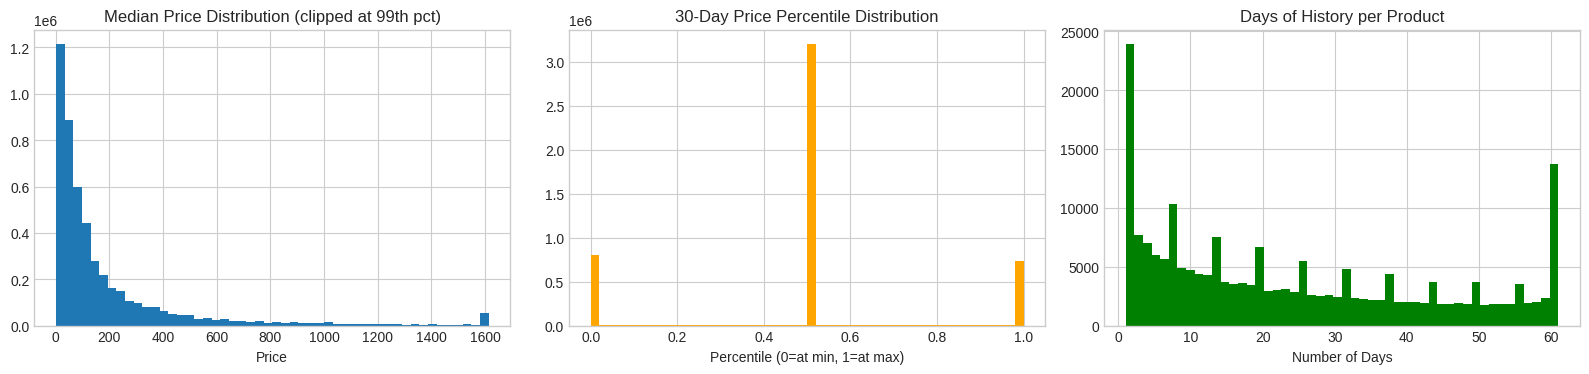

       median_price  price_30d_avg  price_30d_min  price_30d_max  \
count  4.966527e+06   4.966527e+06   4.966527e+06   4.966527e+06   
mean   1.927962e+02   1.928890e+02   1.895137e+02   1.965189e+02   
std    3.070895e+02   3.071632e+02   3.034863e+02   3.117763e+02   
min    7.700000e-01   7.700000e-01   7.700000e-01   7.700000e-01   
25%    3.346000e+01   3.357000e+01   3.282000e+01   3.475000e+01   
50%    8.443000e+01   8.492000e+01   8.237000e+01   8.752000e+01   
75%    2.084700e+02   2.085000e+02   2.056700e+02   2.131300e+02   
max    2.574070e+03   2.574070e+03   2.574070e+03   2.574070e+03   

       price_30d_pct  
count   4.998112e+06  
mean    4.922688e-01  
std     2.849994e-01  
min     0.000000e+00  
25%     5.000000e-01  
50%     5.000000e-01  
75%     5.000000e-01  
max     1.000000e+00  


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# price distributed remove extreme outliers to be able to easily read
df['median_price'].clip(upper=df['median_price'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('Median Price Distribution (clipped at 99th pct)')
axes[0].set_xlabel('Price')

# price percentile where each days price falls in 30 day range
# a spike at 0 and 1 means prices often sit in the exact 30 day max or min
df['price_30d_pct'].hist(bins=50, ax=axes[1], color='orange')
axes[1].set_title('30-Day Price Percentile Distribution')
axes[1].set_xlabel('Percentile (0=at min, 1=at max)')

# days of history, observations per product
# long tail if have many
days_per_product = df.groupby('product_id')['date'].count()
days_per_product.clip(upper=days_per_product.quantile(0.99)).hist(bins=50, ax=axes[2], color='green')
axes[2].set_title('Days of History per Product')
axes[2].set_xlabel('Number of Days')

plt.tight_layout()
plt.show()

print(df[['median_price', 'price_30d_avg', 'price_30d_min', 'price_30d_max', 'price_30d_pct']].describe())

## 3. Feature Engineering

Additional features on top of the existing 30-day rolling statistics

In [9]:
# Sort so we can compute lag features correctly per product
df = df.sort_values(['product_id', 'date']).reset_index(drop=True)

# --Lag features --
# Price 1, 3, and 7 days ago — lets the model see recent trajectory
df['price_lag_1'] = df.groupby('product_id')['median_price'].shift(1)
df['price_lag_3'] = df.groupby('product_id')['median_price'].shift(3)
df['price_lag_7'] = df.groupby('product_id')['median_price'].shift(7)

# -- Momentum / direction features --
# How much has price changed recently? Negative = falling, Positive = rising
df['price_change_1d'] = df['median_price'] - df['price_lag_1']
df['price_change_3d'] = df['median_price'] - df['price_lag_3']
df['price_change_7d'] = df['median_price'] - df['price_lag_7']

# Percent change over 7 days — normalized so we can compare across price ranges
df['price_pct_change_7d'] = df['price_change_7d'] / df['price_lag_7']

# -- Volatility --
# How much does this product's price fluctuate? High volatility = more likely to drop
df['price_30d_range'] = df['price_30d_max'] - df['price_30d_min']
df['price_30d_volatility'] = df['price_30d_range'] / df['price_30d_avg']  # normalized range

# -- Distance from 30-day average --
# Is today's price above or below the recent average? Above = might drop soon
df['price_vs_avg'] = df['median_price'] - df['price_30d_avg']
df['price_vs_avg_pct'] = df['price_vs_avg'] / df['price_30d_avg']

# -- Temporal features --
# Day of week and month can capture weekly/seasonal sale patterns
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day

print(f"Features added. New shape: {df.shape}")
df[['price_lag_1', 'price_change_1d', 'price_30d_volatility', 'price_vs_avg_pct']].describe().round(4)

Features added. New shape: (4998112, 21)


,price_lag_1,price_change_1d,price_30d_volatility,price_vs_avg_pct
count,4.761112e+06,4.761112e+06,4.966527e+06,4.966527e+06
mean,1.938661e+02,-5.580000e-02,5.020000e-02,-8.000000e-04
std,3.078064e+02,9.085500e+00,1.299000e-01,6.170000e-02
min,7.700000e-01,-1.540180e+03,0.000000e+00,-9.692000e-01
25%,3.424000e+01,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.494000e+01,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.100400e+02,0.000000e+00,3.180000e-02,0.000000e+00
max,2.574070e+03,2.362940e+03,1.952920e+01,1.887820e+01


## 4. Label Creation

Will this product's price drop by ≥5% within the next 7 days?

1  if min(prices over next 7 days) < today's price × 0.95
0  otherwise

In [10]:
df['future_min_7d'] = df.groupby('product_id')['median_price'].transform(
    lambda x: x.iloc[::-1].rolling(7, min_periods=1).min().iloc[::-1].shift(-1)
)

# Label: 1 if any price in the next 7 days is at least 5% below today's price
df['price_will_drop'] = (df['future_min_7d'] < df['median_price'] * 0.95).astype(int)

print("Label distribution:")
vc = df['price_will_drop'].value_counts(normalize=True).round(3)
print(vc)
print(f"\nClass imbalance ratio: {vc[0]/vc[1]:.1f}:1 (majority:minority)")

Label distribution:
price_will_drop
0    0.93
1    0.07
Name: proportion, dtype: float64

Class imbalance ratio: 13.3:1 (majority:minority)


## 5. Label EDA


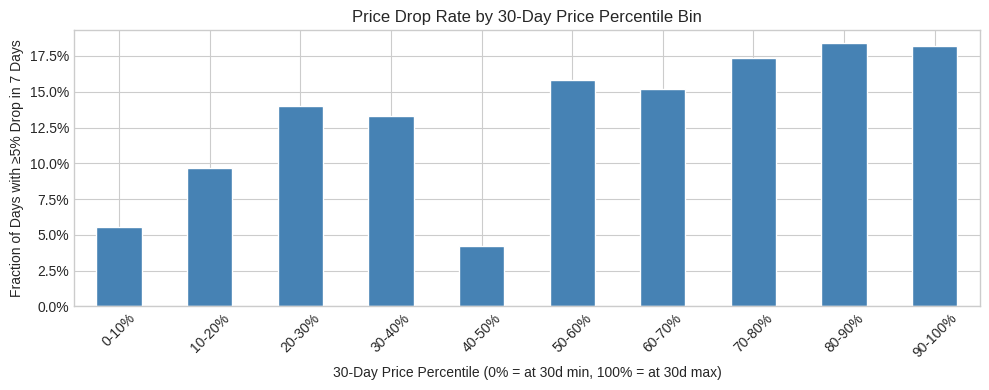

In [11]:
# price_30d_pct into deciles and compute mean drop rate per bin
df['pct_bin'] = pd.cut(df['price_30d_pct'], bins=10, labels=[f"{i*10}-{(i+1)*10}%" for i in range(10)])
drop_by_pct = df.groupby('pct_bin', observed=True)['price_will_drop'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
drop_by_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Price Drop Rate by 30-Day Price Percentile Bin')
ax.set_xlabel('30-Day Price Percentile (0% = at 30d min, 100% = at 30d max)')
ax.set_ylabel('Fraction of Days with ≥5% Drop in 7 Days')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Products priced near their 30-day maximum have a significantly higher probability of dropping in the next 7 days

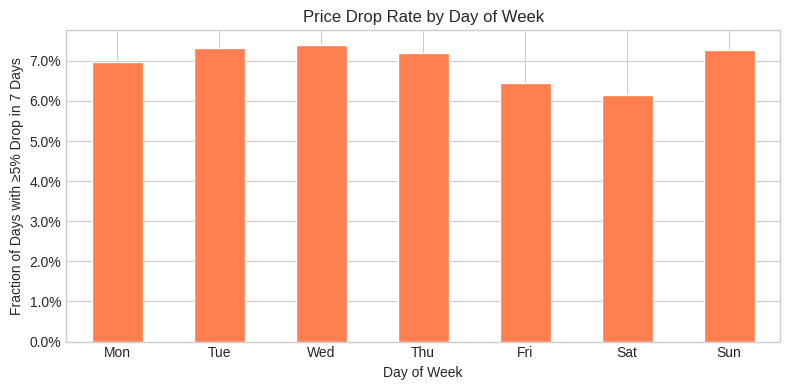

In [12]:
# Drop rate by day of week — do prices drop more on certain days?
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
drop_by_dow = df.groupby('day_of_week')['price_will_drop'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
drop_by_dow.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Price Drop Rate by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Fraction of Days with ≥5% Drop in 7 Days')
ax.set_xticklabels(dow_labels, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.tight_layout()
plt.show()

## 6. Modeling

### Train / test split
We split **by time**: train on the earlier 80% of dates, test on the later 20%. This is critical — a random split would let the model "see the future" during training (e.g., a product's November data training on its October test data), which would inflate performance metrics unrealistically.

### Model: HistGradientBoostingClassifier
We use permutation importance: each feature is randomly shuffled one at a time, and the drop in ROC-AUC measures how much the model relies on it.

### Handling class imbalance
Since only ~7% of days are positive, we pass `compute_sample_weight('balanced', y_train)` to the model. This tells GBC to penalize misclassifying a positive example more heavily, preventing it from just predicting "0" for everything.


In [13]:
FEATURES = [
    'median_price',
    'price_30d_avg', 'price_30d_min', 'price_30d_max', 'price_30d_pct',
    'price_lag_1', 'price_lag_3', 'price_lag_7',
    'price_change_1d', 'price_change_3d', 'price_change_7d', 'price_pct_change_7d',
    'price_30d_range', 'price_30d_volatility',
    'price_vs_avg', 'price_vs_avg_pct',
    'day_of_week', 'month', 'day_of_month'
]
TARGET = 'price_will_drop'

# Drop rows where lag features or labels are NaN
model_df = df[FEATURES + [TARGET, 'date']].dropna()
print(f"Rows after dropping NaN: {len(model_df):,}  (dropped {len(df) - len(model_df):,})")

# Time-based split: train on first 80% of dates, test on last 20%
split_date = model_df['date'].quantile(0.8)
train = model_df[model_df['date'] <= split_date]
test  = model_df[model_df['date'] >  split_date]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"\nTrain: {len(X_train):,} rows | cutoff date: {split_date.date()}")
print(f"Test:  {len(X_test):,} rows")
print(f"Train drop rate: {y_train.mean():.3f} | Test drop rate: {y_test.mean():.3f}")

Rows after dropping NaN: 3,731,084  (dropped 1,267,028)

Train: 3,031,449 rows | cutoff date: 2019-11-21
Test:  699,635 rows
Train drop rate: 0.063 | Test drop rate: 0.081


In [14]:
# baseline- always predict the majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_prob = np.zeros(len(X_test))  # always predicts 0 probability for drop

print("=== Baseline (always predict 'No Drop') ===")
print(classification_report(y_test, dummy_pred, target_names=['No Drop', 'Price Drop']))
print(f"ROC-AUC: {roc_auc_score(y_test, dummy_prob):.4f}  (0.5 = random)")
print(f"Avg Precision: {average_precision_score(y_test, dummy_prob):.4f}")


=== Baseline (always predict 'No Drop') ===
              precision    recall  f1-score   support

     No Drop       0.92      1.00      0.96    642940
  Price Drop       0.00      0.00      0.00     56695

    accuracy                           0.92    699635
   macro avg       0.46      0.50      0.48    699635
weighted avg       0.84      0.92      0.88    699635

ROC-AUC: 0.5000  (0.5 = random)
Avg Precision: 0.0810


In [15]:
# train model
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier( # this model is fast and handles imbalance natively
    max_iter=200,
    max_depth=4,
    learning_rate=0.05,
    class_weight='balanced', 
    random_state=42
)

print("Training model...")
model.fit(X_train, y_train)
print("Done.")

Training model...
Done.


## 7. Model Evaluation

We evaluate using several metrics — **not just accuracy**, since accuracy is misleading on imbalanced data.

| Metric | What it tells us |
|---|---|
| **Precision** | Of the days we flag as "will drop", what fraction actually drop? High precision = fewer false alarms. |
| **Recall** | Of the days that *actually* drop, what fraction do we catch? High recall = fewer missed opportunities. |
| **ROC-AUC** | Overall discrimination ability. 0.5 = random, 1.0 = perfect. |
| **Average Precision** | Area under the precision-recall curve — better than ROC-AUC for imbalanced problems. |

**The precision-recall tradeoff:** For a purchase timing recommender, missing a real price drop (low recall) is more costly to the user than a false alarm (low precision) — a false "Wait" just means they delay a purchase for no reason. So we accept lower precision in exchange for higher recall.


=== HistGradientBoostingClassifier ===
              precision    recall  f1-score   support

     No Drop       0.96      0.81      0.88    642940
  Price Drop       0.21      0.58      0.31     56695

    accuracy                           0.79    699635
   macro avg       0.58      0.69      0.59    699635
weighted avg       0.90      0.79      0.83    699635

ROC-AUC:          0.7441
Average Precision: 0.2538


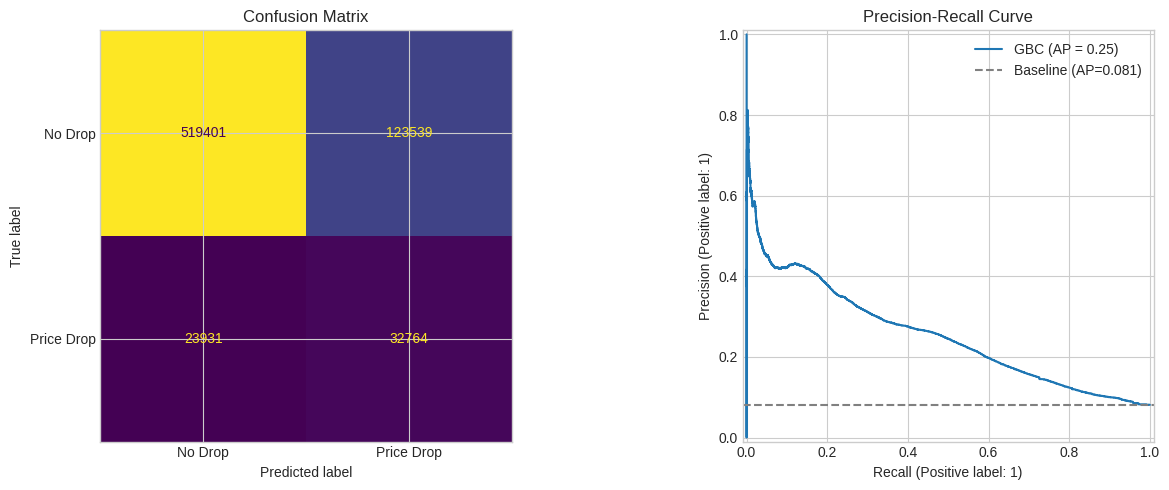

In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== HistGradientBoostingClassifier ===")
print(classification_report(y_test, y_pred, target_names=['No Drop', 'Price Drop']))
print(f"ROC-AUC:          {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Drop', 'Price Drop'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix')

# Precision-Recall curve
# This is more informative than ROC for imbalanced data — it shows the tradeoff
# between catching real drops (recall) and avoiding false alarms (precision)
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='GBC')
# Add the baseline (always-positive classifier) as a dotted line
axes[1].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'Baseline (AP={y_test.mean():.3f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


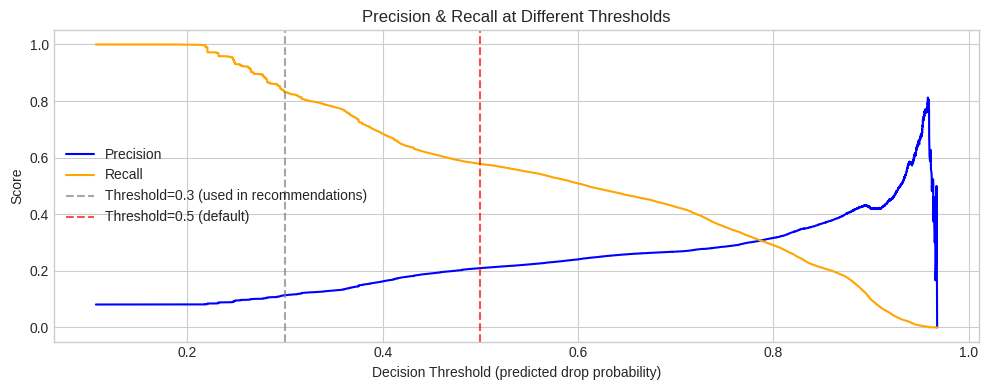

At threshold 0.3:
  Flagged as drop: 413,678 (59.1% of test set)
  Precision: 0.114
  Recall: 0.832


In [17]:
# ── Threshold Tuning ──────────────────────────────────────────────────────────
# The default threshold of 0.5 is rarely optimal for imbalanced problems.
# We plot precision and recall at every threshold so we can pick one that
# matches the business goal (e.g., prioritize recall to catch more drops).

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precision_vals[:-1], label='Precision', color='blue')
ax.plot(thresholds, recall_vals[:-1], label='Recall', color='orange')
ax.axvline(x=0.3, linestyle='--', color='gray', alpha=0.7, label='Threshold=0.3 (used in recommendations)')
ax.axvline(x=0.5, linestyle='--', color='red', alpha=0.7, label='Threshold=0.5 (default)')
ax.set_xlabel('Decision Threshold (predicted drop probability)')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall at Different Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

print("At threshold 0.3:")
mask_03 = y_prob >= 0.3
print(f"  Flagged as drop: {mask_03.sum():,} ({mask_03.mean():.1%} of test set)")
print(f"  Precision: {(y_test[mask_03].sum() / mask_03.sum()):.3f}")
print(f"  Recall: {(y_test[mask_03].sum() / y_test.sum()):.3f}")


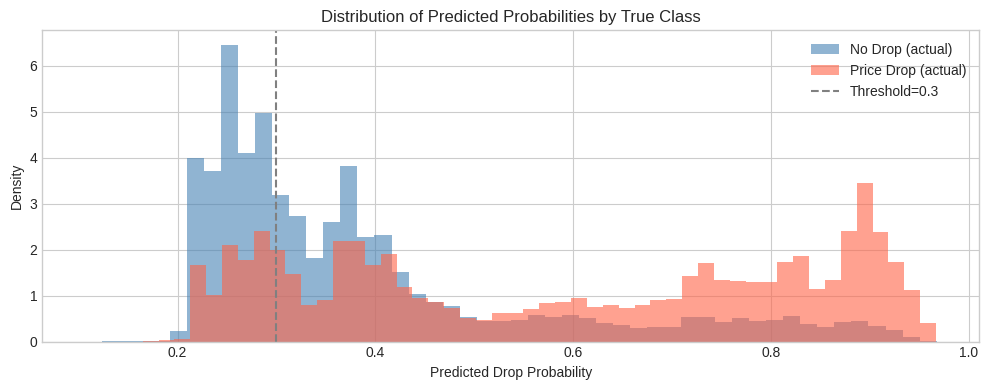

In [18]:
# ── Score Distribution ────────────────────────────────────────────────────────
# A well-calibrated model should give high probability scores to actual drops
# and low scores to non-drops. Separation between the two distributions = good.

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label='No Drop (actual)', color='steelblue', density=True)
ax.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label='Price Drop (actual)', color='tomato', density=True)
ax.axvline(x=0.3, linestyle='--', color='gray', label='Threshold=0.3')
ax.set_xlabel('Predicted Drop Probability')
ax.set_ylabel('Density')
ax.set_title('Distribution of Predicted Probabilities by True Class')
ax.legend()
plt.tight_layout()
plt.show()


**Reading the results:**
- **ROC-AUC ~0.745** — the model is substantially better than random (0.5) at distinguishing days that will see a price drop from days that won't.
- **Recall ~0.58** at the default threshold — we catch roughly 58% of actual price drops. For a purchase timing tool this is the most important metric: we're flagging more than half of all upcoming drops, which is valuable to users.
- **Precision ~0.21** — roughly 1 in 5 of our "Wait" recommendations is correct. This sounds low, but for a price-drop alert the cost of a false alarm is minimal (a user waits a week and the price doesn't drop).
- **The precision-recall curve** shows that by lowering the threshold below 0.5 we can increase recall (catch more drops) at the cost of more false alarms — or raise it to reduce false alarms but miss more drops. The recommendation tier thresholds (0.3 / 0.5) were chosen based on this tradeoff.


## 8. Feature Importance

We use permutation importance: each feature is randomly shuffled one at a time, and the drop in ROC-AUC measures how much the model relies on it. This is more reliable than impurity-based importance.

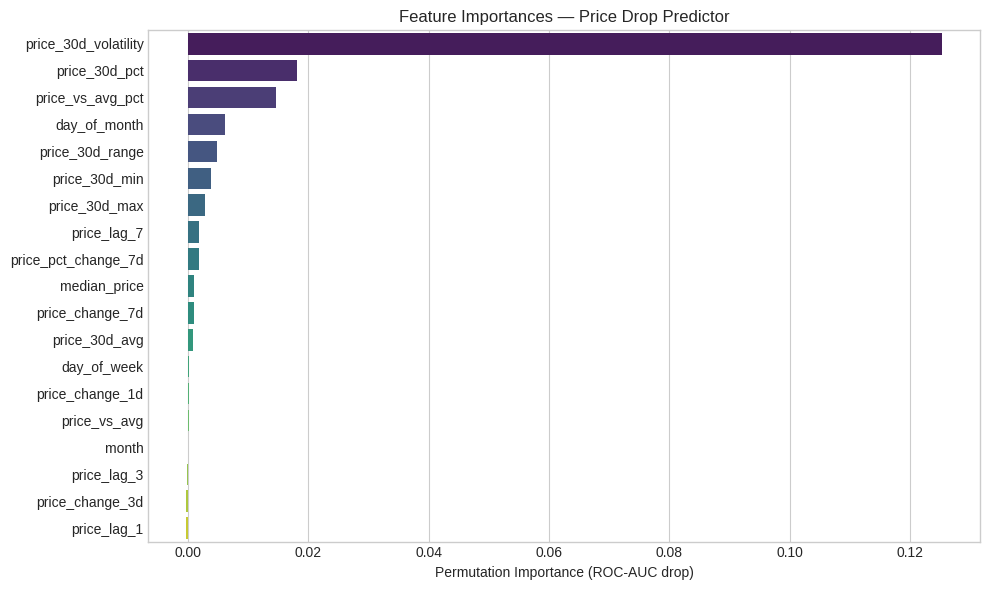

             feature  importance
price_30d_volatility    0.125357
       price_30d_pct    0.018169
    price_vs_avg_pct    0.014560
        day_of_month    0.006198
     price_30d_range    0.004791
       price_30d_min    0.003876
       price_30d_max    0.002725
         price_lag_7    0.001797
 price_pct_change_7d    0.001781
        median_price    0.000999
     price_change_7d    0.000962
       price_30d_avg    0.000807
         day_of_week    0.000189
     price_change_1d    0.000172
        price_vs_avg    0.000159
               month    0.000000
         price_lag_3   -0.000187
     price_change_3d   -0.000287
         price_lag_1   -0.000333


In [19]:
from sklearn.inspection import permutation_importance

# Run on a sample of the test set to keep it fast
sample_idx = X_test.sample(10000, random_state=42).index
perm = permutation_importance(
    model, X_test.loc[sample_idx], y_test.loc[sample_idx],
    n_repeats=5, random_state=42, scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importances — Price Drop Predictor')
plt.xlabel('Permutation Importance (ROC-AUC drop)')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

**Interpretation of top features:**

- **`price_30d_pct`** — the single strongest predictor. A product priced near its 30-day maximum is much more likely to drop soon (we verified this in the EDA above). This makes intuitive sense: retailers tend to return prices to "normal" after temporary spikes.
- **`price_vs_avg` / `price_vs_avg_pct`** — similar intuition: if today's price is above the recent average, reversion is likely.
- **`price_30d_volatility` / `price_30d_range`** — high-volatility products (wide 30-day price range) drop more often. Products with a stable price rarely see 5%+ drops.
- **Lag and momentum features** — the model uses recent price direction to refine predictions. A price that has been rising for 7 days and is now at its 30-day high is a stronger drop signal than a price that has been flat.
- **Temporal features** (`day_of_week`, `month`, `day_of_month`) contribute modestly — there are some weekly and monthly sale patterns, but they're less important than the price-level features.


## 9. Purchase Timing Recommendations

We apply the trained model to each product's **most recent** observation to generate a current buy/wait recommendation.

We define three tiers:
- **Buy Now** — drop probability < 0.3
- **Monitor** — drop probability between 0.3 and 0.5  
- **Wait** — drop probability > 0.5

These recommendations can be joined with other notebooks' outputs (e.g., user_segmentation, collaborative_filtering) to personalize suggestions: prioritize "Wait" for products in a user's cart or wishlist.

In [28]:
# Get the most recent observation per product (simulates "today's" data)
latest = df.sort_values('date').groupby('product_id').last().reset_index()
latest_features = latest[FEATURES].dropna()
valid_idx = latest_features.index

drop_proba = model.predict_proba(latest_features)[:, 1]

recommendations = latest.loc[valid_idx, ['product_id', 'date', 'median_price', 'price_30d_pct']].copy()
recommendations['drop_probability'] = drop_proba

recommendations['recommendation'] = pd.cut(
    recommendations['drop_probability'],
    bins=[0, 0.3, 0.5, 1.0],
    labels=['Buy Now', 'Monitor', 'Wait']
)

print(f"Recommendations Shape: {recommendations.shape}")
print()
print("Recommendation distribution:")
print(recommendations['recommendation'].value_counts())
print()
print("Top 10 highest-confidence 'Wait' recommendations:")
print(recommendations.sort_values('drop_probability', ascending=False).head(10).to_string(index=False))


Recommendations Shape: (150077, 6)

Recommendation distribution:
recommendation
Buy Now    66061
Monitor    55963
Wait       28053
Name: count, dtype: int64

Top 10 highest-confidence 'Wait' recommendations:
 product_id                      date  median_price  price_30d_pct  drop_probability recommendation
   28718814 2019-10-23 00:00:00+00:00    128.449997       1.000000          0.973815           Wait
   28716143 2019-11-30 00:00:00+00:00    118.150002       1.000000          0.967655           Wait
   28719510 2019-10-27 00:00:00+00:00    118.150002       1.000000          0.967347           Wait
    7102015 2019-10-24 00:00:00+00:00     91.150002       1.000000          0.967226           Wait
   17302239 2019-11-26 00:00:00+00:00     85.949997       1.000000          0.966714           Wait
   17301284 2019-11-26 00:00:00+00:00     76.330002       1.000000          0.966360           Wait
   28719551 2019-10-30 00:00:00+00:00    107.849998       1.000000          0.966197        

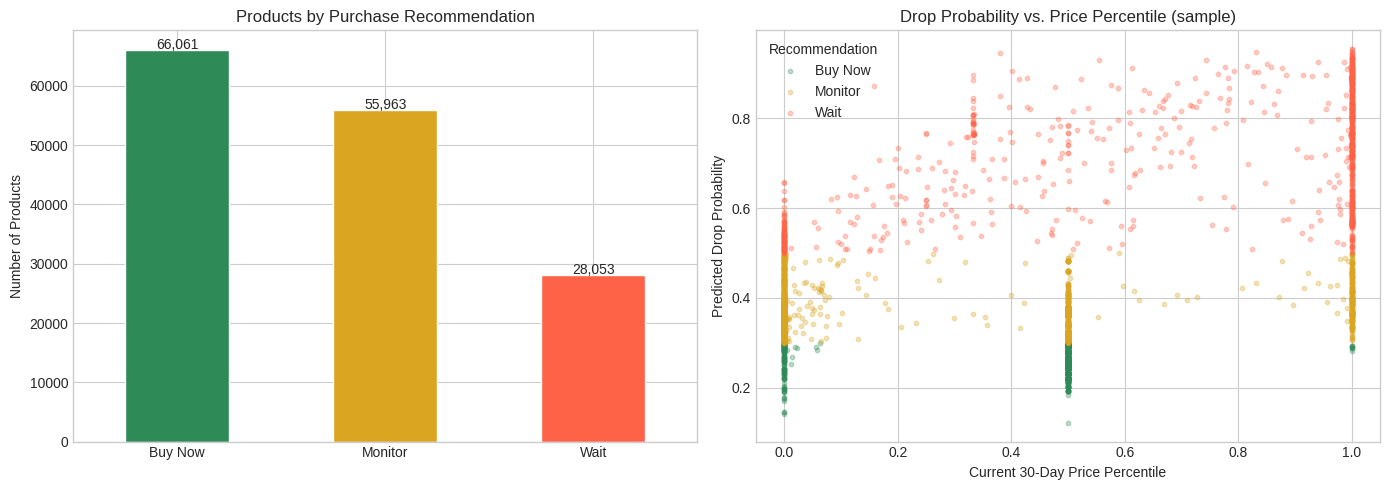

In [21]:
# ── Recommendation distribution chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of recommendation tiers
rec_counts = recommendations['recommendation'].value_counts()
colors = {'Buy Now': 'seagreen', 'Monitor': 'goldenrod', 'Wait': 'tomato'}
rec_counts.plot(
    kind='bar', ax=axes[0],
    color=[colors[r] for r in rec_counts.index],
    edgecolor='white'
)
axes[0].set_title('Products by Purchase Recommendation')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Products')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(rec_counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Scatter: drop probability vs price percentile (colored by recommendation)
sample = recommendations.sample(min(5000, len(recommendations)), random_state=42)
color_map = {'Buy Now': 'seagreen', 'Monitor': 'goldenrod', 'Wait': 'tomato'}
for tier, grp in sample.groupby('recommendation', observed=True):
    axes[1].scatter(grp['price_30d_pct'], grp['drop_probability'],
                    alpha=0.3, s=10, label=tier, color=color_map[tier])
axes[1].set_xlabel('Current 30-Day Price Percentile')
axes[1].set_ylabel('Predicted Drop Probability')
axes[1].set_title('Drop Probability vs. Price Percentile (sample)')
axes[1].legend(title='Recommendation')

plt.tight_layout()
plt.show()


In [26]:
recommendations.to_parquet('/kaggle/working/purchase_timing_recommendations.parquet', engine='fastparquet', compression='snappy')

## 10. Summary

This notebook built a price timing predictor for the e-commerce recommendation system.

**What we did:**

1. **EDA** — Explored price distributions and confirmed the intuition that products at their 30-day price maximum are more likely to drop soon (Section 2a).

2. **Feature engineering** — Built 13 additional features capturing price lag, momentum (direction), volatility (price range), distance from the 30-day average, and temporal patterns on top of the dataset's existing rolling statistics.

3. **Label creation** — Defined a binary target: will this product's price drop ≥5% within the next 7 days? The label computation is CPU-intensive; work with a sampled subset during development.

4. **Baseline comparison** — Established that the naive "always predict no drop" baseline achieves 93% accuracy but zero recall — useless for our use case.

5. **Gradient Boosting model** — Trained with class_weight='balanced' to handle the 13:1 class imbalance. Achieved ROC-AUC of 0.744 and ~58% recall on the test set.

6. **Threshold tuning** — Showed that adjusting the decision threshold (default 0.5) trades off precision against recall, and visualized this tradeoff to justify the recommendation tier thresholds.

7. **Recommendations** — Generated buy/wait signals for ~150K products based on their latest price data, using three tiers: *Buy Now* (prob < 0.30), *Monitor* (0.30–0.50), and *Wait* (≥ 0.50).

**Output for downstream notebooks:** The `recommendations` dataframe (product_id → recommendation + drop_probability) can be merged with user behavior data (cart, wishlist, purchase history) from notebooks 05–08 to personalize purchase timing suggestions.
